<a href="https://colab.research.google.com/github/vananhnt2801/Carbon-Price-Forecasting/blob/main/%5B19_08_26_Reimplementation%5D_Smart_forecasting_of_carbon_prices_using_machine_learning_and_neural_networks_when_ARIMA_meets_XGBOOST_and_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance xgboost tensorflow statsmodels scikit-learn -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import xgboost as xgb

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [3]:
start_date = "2020-01-01"   # KRBN chỉ có dữ liệu từ khoảng 2020 trở đi
end_date   = "2025-01-10"

carbon = yf.download("KRBN", start=start_date, end=end_date)[["Close"]]
esg    = yf.download("SUSA", start=start_date, end=end_date)[["Close"]]

carbon.columns = ["CARBON_PRICE"]
esg.columns    = ["ESG_INDEX"]

df = carbon.join(esg, how="inner").dropna()
df.index.name = "Date"
df = df.reset_index()

print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

(1117, 3)


,Date,CARBON_PRICE,ESG_INDEX
0,2020-07-31,14.057076,66.010666
1,2020-08-03,14.116426,66.675407
2,2020-08-04,14.281365,66.703300
3,2020-08-05,14.375221,67.144928
4,2020-08-06,14.186818,67.493576


               count       mean        std        min        25%        50%  \
CARBON_PRICE  1117.0  28.161707   5.993649  13.084695  26.055531  29.525784   
ESG_INDEX     1117.0  90.815028  13.431309  65.969185  81.367706  88.566483   

                    75%         max      skew      kurt  
CARBON_PRICE  32.516956   38.833652 -1.066550  0.231923  
ESG_INDEX     98.283043  124.913765  0.622832 -0.150767  


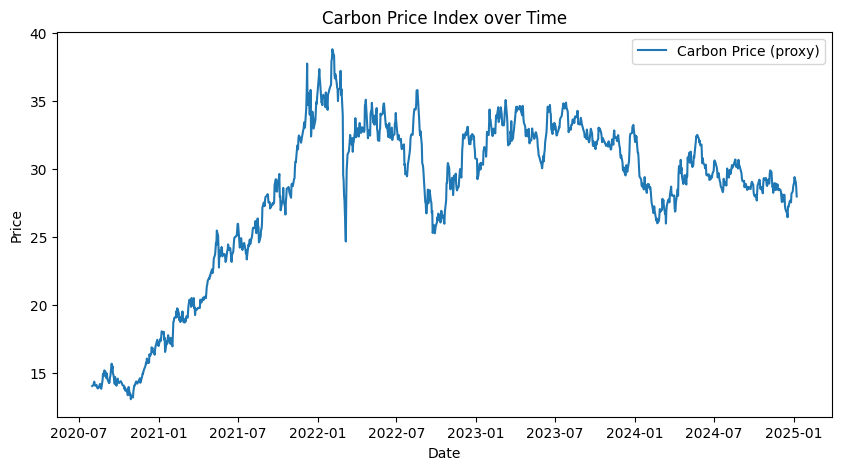

In [4]:
desc = df[["CARBON_PRICE", "ESG_INDEX"]].describe().T
desc["skew"] = df[["CARBON_PRICE", "ESG_INDEX"]].skew()
desc["kurt"] = df[["CARBON_PRICE", "ESG_INDEX"]].kurt()
print(desc)

plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["CARBON_PRICE"], label="Carbon Price (proxy)")
plt.title("Carbon Price Index over Time")
plt.xlabel("Date"); plt.ylabel("Price")
plt.legend()
plt.show()

In [5]:
def adf_report(series, name):
    result = adfuller(series.dropna())
    print(f"{name}: ADF stat = {result[0]:.4f}, p-value = {result[1]:.4f}")
    return result[1]

p1 = adf_report(df["CARBON_PRICE"], "CARBON_PRICE (level)")
p2 = adf_report(df["CARBON_PRICE"].diff(), "CARBON_PRICE (1st diff)")

p3 = adf_report(df["ESG_INDEX"], "ESG_INDEX (level)")
p4 = adf_report(df["ESG_INDEX"].diff(), "ESG_INDEX (1st diff)")

CARBON_PRICE (level): ADF stat = -2.4727, p-value = 0.1222
CARBON_PRICE (1st diff): ADF stat = -21.8594, p-value = 0.0000
ESG_INDEX (level): ADF stat = -0.8385, p-value = 0.8076
ESG_INDEX (1st diff): ADF stat = -32.6988, p-value = 0.0000


In [6]:
n = len(df)
train_size = int(n * 0.85)   # 85% train, 15% test

train = df.iloc[:train_size].reset_index(drop=True)
test  = df.iloc[train_size:].reset_index(drop=True)

print("Train size:", len(train), "| Test size:", len(test))

Train size: 949 | Test size: 168


In [10]:
# Lấy đúng các ngày test giống XGBoost/LSTM (từ full_feat, Bước 8)
test_dates = full_feat["Date"].iloc[split_idx:].reset_index(drop=True)
actual_values = y_test.reset_index(drop=True)   # = full_feat["CARBON_PRICE"] tại các ngày test

# Lịch sử ban đầu cho ARIMA: toàn bộ dữ liệu TRƯỚC ngày test đầu tiên
first_test_date = test_dates.iloc[0]
history = list(df.loc[df["Date"] < first_test_date, "CARBON_PRICE"])

print(f"ARIMA history length: {len(history)} | Test length: {len(test_dates)}")

arima_preds_aligned = []

for t in range(len(actual_values)):
    model = ARIMA(history, order=(2,1,5))
    fitted = model.fit()
    yhat = fitted.forecast(steps=1)[0]
    arima_preds_aligned.append(yhat)
    history.append(actual_values.iloc[t])   # one-step-ahead: cập nhật giá trị thật

arima_preds_aligned = np.array(arima_preds_aligned)

rmse_arima = np.sqrt(mean_squared_error(actual_values, arima_preds_aligned))
mae_arima  = mean_absolute_error(actual_values, arima_preds_aligned)
print(f"ARIMA (aligned) -> RMSE: {rmse_arima:.2f}, MAE: {mae_arima:.2f}")

ARIMA history length: 950 | Test length: 167
ARIMA (aligned) -> RMSE: 0.36, MAE: 0.29


In [8]:
def create_lag_features(data, target_col, exog_col, n_lags=5):
    df_feat = data.copy()
    for lag in range(1, n_lags+1):
        df_feat[f"{target_col}_lag{lag}"] = df_feat[target_col].shift(lag)
        df_feat[f"{exog_col}_lag{lag}"] = df_feat[exog_col].shift(lag)
    df_feat = df_feat.dropna().reset_index(drop=True)
    return df_feat

n_lags = 5
full_feat = create_lag_features(df, "CARBON_PRICE", "ESG_INDEX", n_lags)

feature_cols = [c for c in full_feat.columns if "lag" in c]
X = full_feat[feature_cols]
y = full_feat["CARBON_PRICE"]

split_idx = int(len(full_feat) * 0.85)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.2,
    max_depth=5,
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_preds))
mae_xgb  = mean_absolute_error(y_test, xgb_preds)
print(f"XGBoost -> RMSE: {rmse_xgb:.2f}, MAE: {mae_xgb:.2f}")

XGBoost -> RMSE: 0.47, MAE: 0.37


In [9]:
scaler_y = MinMaxScaler()
scaler_x = MinMaxScaler()

X_train_s = scaler_x.fit_transform(X_train)
X_test_s  = scaler_x.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_s  = scaler_y.transform(y_test.values.reshape(-1,1))

X_train_lstm = X_train_s.reshape((X_train_s.shape[0], 1, X_train_s.shape[1]))
X_test_lstm  = X_test_s.reshape((X_test_s.shape[0], 1, X_test_s.shape[1]))

lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

lstm_model.fit(
    X_train_lstm, y_train_s,
    validation_split=0.1,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

lstm_preds_s = lstm_model.predict(X_test_lstm)
lstm_preds = scaler_y.inverse_transform(lstm_preds_s).flatten()

rmse_lstm = np.sqrt(mean_squared_error(y_test, lstm_preds))
mae_lstm  = mean_absolute_error(y_test, lstm_preds)
print(f"LSTM -> RMSE: {rmse_lstm:.2f}, MAE: {mae_lstm:.2f}")

Epoch 1/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.2481 - val_loss: 0.0116
Epoch 2/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0220 - val_loss: 0.0648
Epoch 3/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0141 - val_loss: 0.0230
Epoch 4/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0109 - val_loss: 0.0239
Epoch 5/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0098 - val_loss: 0.0188
Epoch 6/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0091 - val_loss: 0.0140
Epoch 7/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0077 - val_loss: 0.0100
Epoch 8/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0062 - val_loss: 0.0070
Epoch 9/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0061 - val_loss: 0.0047
Epoch 10/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0052 - val_loss: 0.0026
Epoch 11/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0047 - val_loss: 0.0021
Epoch 12/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

In [11]:
w = 0.25   # trọng số cho XGBoost (giống Hybrid_1 trong bài báo: 25% XGBoost, 75% LSTM)

hybrid_preds = w * xgb_preds + (1 - w) * lstm_preds

rmse_hybrid = np.sqrt(mean_squared_error(y_test, hybrid_preds))
mae_hybrid  = mean_absolute_error(y_test, hybrid_preds)
print(f"Hybrid -> RMSE: {rmse_hybrid:.2f}, MAE: {mae_hybrid:.2f}")

results = pd.DataFrame({
    "Model": ["ARIMA (test subset)", "XGBoost", "LSTM", "Hybrid"],
    "RMSE": [None, rmse_xgb, rmse_lstm, rmse_hybrid],
    "MAE":  [None, mae_xgb, mae_lstm, mae_hybrid]
})
print(results)

Hybrid -> RMSE: 0.40, MAE: 0.32
                 Model      RMSE       MAE
0  ARIMA (test subset)       NaN       NaN
1              XGBoost  0.465580  0.373575
2                 LSTM  0.415583  0.331896
3               Hybrid  0.403278  0.318514


In [12]:
from scipy.stats import norm

def diebold_mariano_test(actual, pred1, pred2):
    e1 = np.array(actual) - np.array(pred1)
    e2 = np.array(actual) - np.array(pred2)
    d = e1**2 - e2**2   # loss function: squared error
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)
    dm_stat = mean_d / np.sqrt(var_d / len(d))
    p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

# Giờ actual_values, arima_preds_aligned, xgb_preds, lstm_preds, hybrid_preds
# đều cùng độ dài và cùng khoảng ngày -> so sánh công bằng

pairs = {
    "ARIMA vs XGBoost": (arima_preds_aligned, xgb_preds),
    "ARIMA vs LSTM":    (arima_preds_aligned, lstm_preds),
    "LSTM vs XGBoost":  (lstm_preds, xgb_preds),
    "Hybrid vs XGBoost":(hybrid_preds, xgb_preds),
    "Hybrid vs LSTM":   (hybrid_preds, lstm_preds),
    "Hybrid vs ARIMA":  (hybrid_preds, arima_preds_aligned),
}

dm_results = []
for name, (p1, p2) in pairs.items():
    stat, pval = diebold_mariano_test(actual_values, p1, p2)
    dm_results.append({"Comparison": name, "DM_stat": stat, "p_value": pval})

dm_table = pd.DataFrame(dm_results)
print(dm_table)

          Comparison   DM_stat   p_value
0   ARIMA vs XGBoost -4.722071  0.000002
1      ARIMA vs LSTM -3.000850  0.002692
2    LSTM vs XGBoost -2.380404  0.017294
3  Hybrid vs XGBoost -3.798547  0.000146
4     Hybrid vs LSTM -2.014087  0.044000
5    Hybrid vs ARIMA  2.498395  0.012476


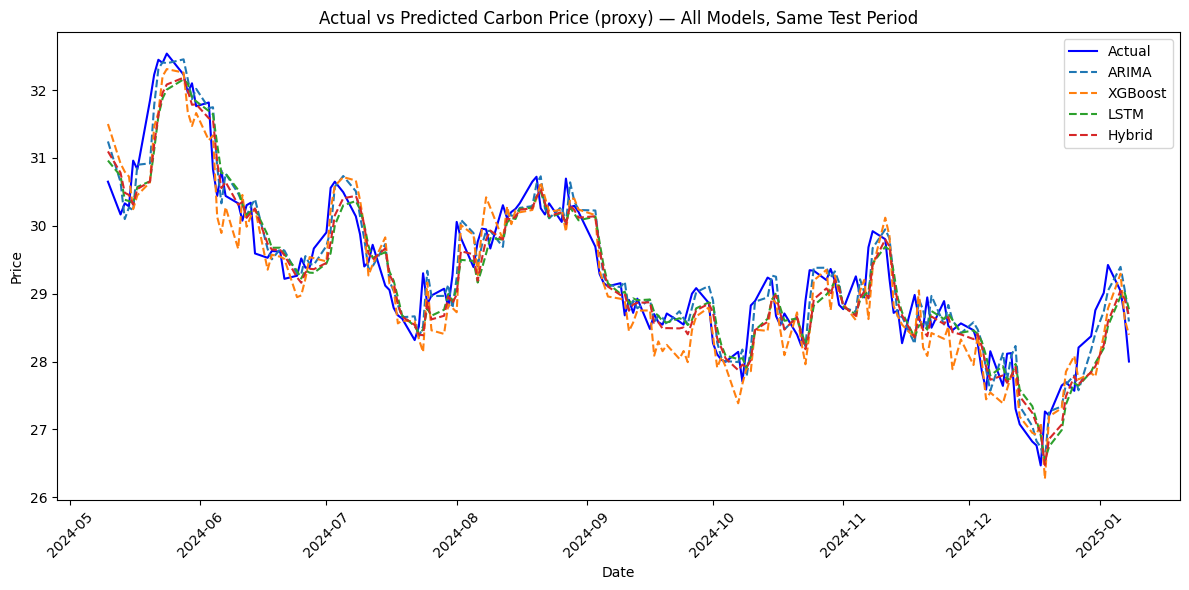

In [13]:
plt.figure(figsize=(12,6))
plt.plot(test_dates, actual_values, label="Actual", color="blue")
plt.plot(test_dates, arima_preds_aligned, label="ARIMA", linestyle="--")
plt.plot(test_dates, xgb_preds, label="XGBoost", linestyle="--")
plt.plot(test_dates, lstm_preds, label="LSTM", linestyle="--")
plt.plot(test_dates, hybrid_preds, label="Hybrid", linestyle="--")
plt.title("Actual vs Predicted Carbon Price (proxy) — All Models, Same Test Period")
plt.xlabel("Date"); plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
results_final = pd.DataFrame({
    "Model": ["ARIMA", "XGBoost", "LSTM", "Hybrid"],
    "RMSE": [
        rmse_arima,
        np.sqrt(mean_squared_error(actual_values, xgb_preds)),
        np.sqrt(mean_squared_error(actual_values, lstm_preds)),
        np.sqrt(mean_squared_error(actual_values, hybrid_preds)),
    ],
    "MAE": [
        mae_arima,
        mean_absolute_error(actual_values, xgb_preds),
        mean_absolute_error(actual_values, lstm_preds),
        mean_absolute_error(actual_values, hybrid_preds),
    ]
})
print(results_final)

     Model      RMSE       MAE
0    ARIMA  0.360416  0.287599
1  XGBoost  0.465580  0.373575
2     LSTM  0.415583  0.331896
3   Hybrid  0.403278  0.318514
